# **Pistachio Variety Classification**

##### **Image Classification with CNN and Transfer Learning**


This project develops a computer vision model to classify Kirmizi and Siirt pistachio varieties based on image data. The dataset contains 2,148 high-resolution images of both varieties. The workflow includes image preprocessing and CNN-based transfer learning to distinguish the varieties using visual characteristics.

<img src='https://pfst.cf2.poecdn.net/base/image/a04bb4cda3a2aeccab00a81079089c48ebe0284033f77d161b2b3ccb6fa8c4dd?w=1024&h=768&pmaid=260299863' width='800'>
<a href='https://www.muratkoklu.com/datasets/' target=_blank>
Click here for the dataset </a>

**Import library**

In [4]:
import os
import pandas as pd

import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", DeprecationWarning)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path = '/content/drive/MyDrive/Pistachio_Image_Dataset'

In [5]:
os.listdir('/content/drive/MyDrive/Pistachio_Image_Dataset')

['Pistachio_Image_Dataset_Request.txt',
 'Pistachio_Image_Dataset',
 'Pistachio_16_Features_Dataset',
 'Pistachio_28_Features_Dataset']

In [12]:
os.listdir('/content/drive/MyDrive/Pistachio_Image_Dataset/Pistachio_Image_Dataset')

['Pistachio_Image_Dataset_Request.txt', 'Siirt_Pistachio', 'Kirmizi_Pistachio']

In [6]:
file_path = '/content/drive/MyDrive/Pistachio_Image_Dataset/Pistachio_Image_Dataset'

In [11]:
# Path to the folders in Google Drive
file_path_kirmizi = '/content/drive/MyDrive/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Kirmizi_Pistachio'
file_path_siirt = '/content/drive/MyDrive/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Siirt_Pistachio'

In [13]:
# Lists the image files in the folders
kirmizi_images = os.listdir(file_path_kirmizi)
siirt_images = os.listdir(file_path_siirt)

In [14]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

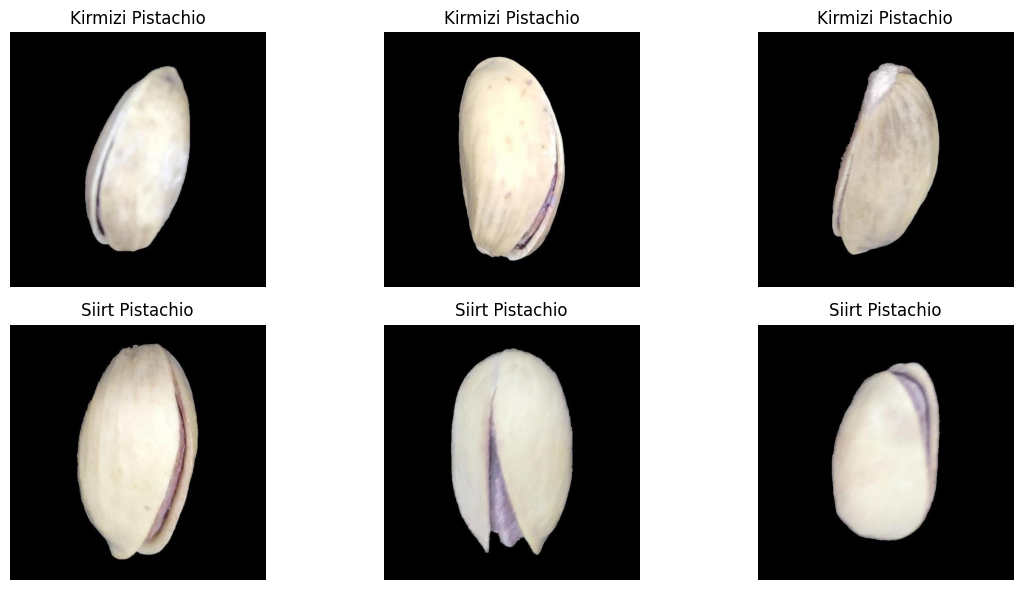

In [15]:
# Paths to the image folders
file_path_kirmizi = '/content/drive/MyDrive/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Kirmizi_Pistachio'
file_path_siirt = '/content/drive/MyDrive/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Siirt_Pistachio'

# Create a list of image files
kirmizi_images = os.listdir(file_path_kirmizi)
siirt_images = os.listdir(file_path_siirt)

# Select random images
random_kirmizi = random.sample(kirmizi_images, 3)  # 3 zufällige Bilder aus Kirmizi
random_siirt = random.sample(siirt_images, 3)      # 3 zufällige Bilder aus Siirt

# Create a grid with 2 rows and 3 columns
fig, axs = plt.subplots(2, 3, figsize=(12, 6))

# Show pictures from Kirmizi
for i, img_name in enumerate(random_kirmizi):
    img = mpimg.imread(os.path.join(file_path_kirmizi, img_name))
    axs[0, i].imshow(img)
    axs[0, i].axis('off')
    axs[0, i].set_title('Kirmizi Pistachio')

# Show pictures from Siirt
for i, img_name in enumerate(random_siirt):
    img = mpimg.imread(os.path.join(file_path_siirt, img_name))
    axs[1, i].imshow(img)
    axs[1, i].axis('off')
    axs[1, i].set_title('Siirt Pistachio')

# Display the grid
plt.tight_layout()
plt.show()

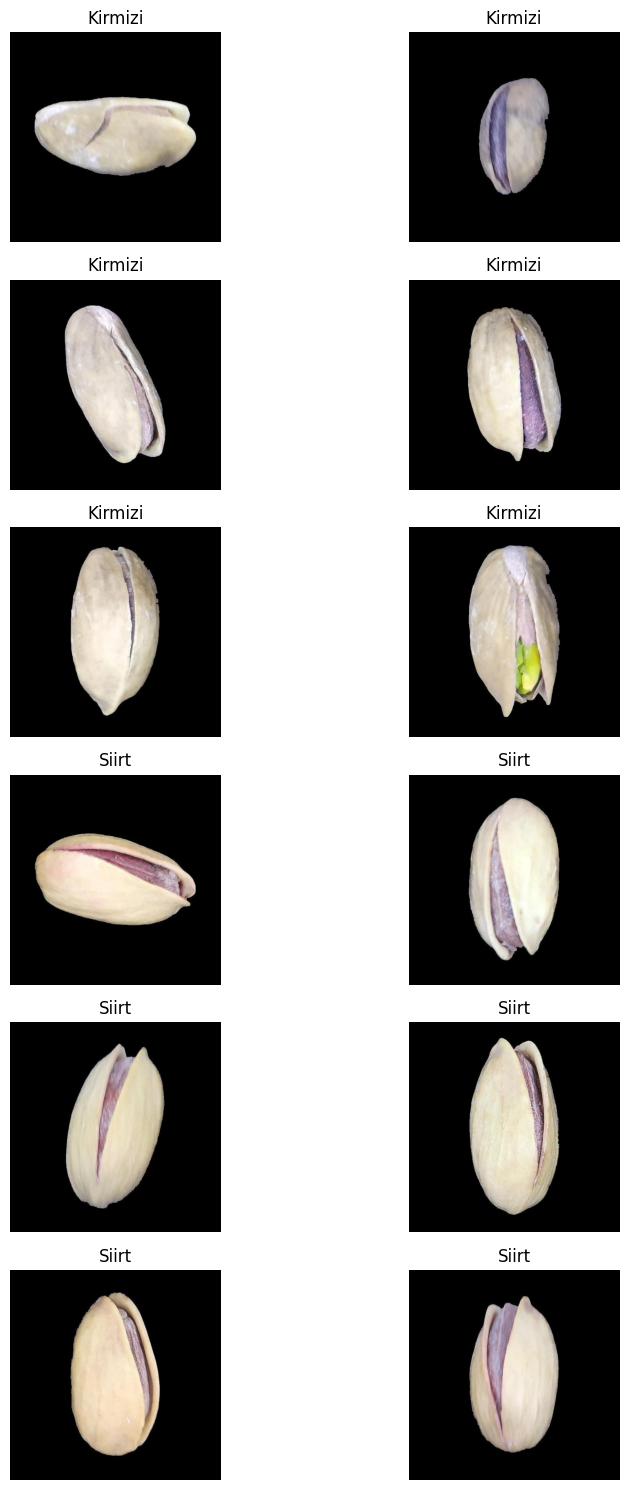

In [18]:
# Read in images and select the first 12 (6 from each folder)
kirmizi_images = [f for f in os.listdir(file_path_kirmizi) if f.endswith(('.jpg', '.png'))][:6]
siirt_images = [f for f in os.listdir(file_path_siirt) if f.endswith(('.jpg', '.png'))][:6]

# Combine the lists
sample_images = kirmizi_images + siirt_images
labels = ['Kirmizi'] * len(kirmizi_images) + ['Siirt'] * len(siirt_images)

# Pictures show
plt.figure(figsize=(10, 15))
for i, img_name in enumerate(sample_images):
    img_path = os.path.join(file_path_kirmizi if i < 6 else file_path_siirt, img_name)
    img = mpimg.imread(img_path)
    plt.subplot(6, 2, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(labels[i])  # Add title

plt.tight_layout()
plt.show()

In [19]:
# Initialize lists for images and labels - (Listen für Bilder und Labels initialisieren)
img_list = []
label_list = []

In [21]:
# Read images into the “Kirmizi” folder
for img_name in os.listdir(file_path_kirmizi):
    img_list.append(os.path.join(file_path_kirmizi, img_name))  # Pfad zum Bild
    label_list.append('kirmizi')  # Label für "Parasitized"

# Read images into the “Siirt” folder
for img_name in os.listdir(file_path_siirt):
    img_list.append(os.path.join(file_path_siirt, img_name))  # Pfad zum Bild
    label_list.append('siirt')

In [22]:
# Dataframe
df = pd.DataFrame({'img': img_list, 'label': label_list})

# Verify that the data was loaded correctly
print(df.head())

# Convert labels to numeric values - (Etiketten in numerische Werte umwandeln)
label_mapping = {'kirmizi': 0, 'siirt': 1}
df['encode_label'] = df['label'].map(label_mapping)

# Check whether the mapping worked correctly
df.head()

                                                 img    label
0  /content/drive/MyDrive/Pistachio_Image_Dataset...  kirmizi
1  /content/drive/MyDrive/Pistachio_Image_Dataset...  kirmizi
2  /content/drive/MyDrive/Pistachio_Image_Dataset...  kirmizi
3  /content/drive/MyDrive/Pistachio_Image_Dataset...  kirmizi
4  /content/drive/MyDrive/Pistachio_Image_Dataset...  kirmizi


,img,label,encode_label
0,/content/drive/MyDrive/Pistachio_Image_Dataset...,kirmizi,0
1,/content/drive/MyDrive/Pistachio_Image_Dataset...,kirmizi,0
2,/content/drive/MyDrive/Pistachio_Image_Dataset...,kirmizi,0
3,/content/drive/MyDrive/Pistachio_Image_Dataset...,kirmizi,0
4,/content/drive/MyDrive/Pistachio_Image_Dataset...,kirmizi,0


In [23]:
df.to_csv('/content/drive/MyDrive/Pistachio_Data.csv', index=False)

**Data Preperation**

In [25]:
import tensorflow as tf

In [26]:
# Pfad zum Datenverzeichnis
data_dir = '/content/drive/MyDrive/Pistachio_Image_Dataset/Pistachio_Image_Dataset'  # Hier den richtigen Pfad angeben

# Datensätze laden
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, image_size=(128, 128), batch_size=16,
    label_mode='categorical', validation_split=0.2, subset='training', seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, image_size=(128, 128), batch_size=16,
    label_mode='categorical', validation_split=0.2, subset='validation', seed=123
)

# Klassennamen und Anzahl der Batches ausgeben
print("Klassennamen:", train_ds.class_names)
print("Anzahl der Trainingsbatches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Anzahl der Validierungsbatches:", tf.data.experimental.cardinality(val_ds).numpy())

Found 2148 files belonging to 2 classes.
Using 1719 files for training.
Found 2148 files belonging to 2 classes.
Using 429 files for validation.
Klassennamen: ['Kirmizi_Pistachio', 'Siirt_Pistachio']
Anzahl der Trainingsbatches: 108
Anzahl der Validierungsbatches: 27


**Modelling Deep Learning**

In [27]:
import numpy as np
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [30]:
# Example: 100 images, 64x64 pixels, 3 color channels
x_train = np.random.rand(100, 64, 64, 3)
y_train = np.random.randint(0, 2, 100)  # Binary labels

In [31]:
# Modell
model = Sequential()
model.add(Conv2D(filters=12, kernel_size=(3, 3), activation="relu", input_shape=(64, 64, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(1, activation="sigmoid"))

# Compile modell
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Check the shapes
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (100, 64, 64, 3)
y_train shape: (100,)


In [32]:
history = model.fit(x_train, y_train, epochs=20, verbose=1)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.5245 - loss: 0.9689
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4689 - loss: 0.8586
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4736 - loss: 0.7458
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6034 - loss: 0.6463
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6435 - loss: 0.6186
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7477 - loss: 0.5829
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9352 - loss: 0.5533
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9845 - loss: 0.5087
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9661 - loss: 0.4804
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8327 - loss: 0.4738
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9908 - loss: 0.4245
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9753 - loss: 0.4154
E

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from sklearn.model_selection import train_test_split
import tensorflow as tf

num_classes = 5  # Number of pistachios
x_data = np.random.rand(100, 64, 64, 3)  # Random training data  (Zufällig)
y_data = np.random.randint(0, num_classes, 100)  # Random labels

# One-Hot-Encoding of the labels
y_data = tf.keras.utils.to_categorical(y_data, num_classes)

# Split test and train data
x_train, x_val, y_train, y_val = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

# Modell
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation="relu", input_shape=(64, 64, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation="softmax"))

# Compile modell
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [36]:
# Train the model with validation data
history = model.fit(x_train, y_train, epochs=20, batch_size=10, validation_data=(x_val, y_val), verbose=1)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.7572 - loss: 0.7258 - val_accuracy: 0.2000 - val_loss: 1.8716
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.7993 - loss: 0.5935 - val_accuracy: 0.2000 - val_loss: 1.9862
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.6317 - loss: 0.7932 - val_accuracy: 0.2000 - val_loss: 1.8578
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.7681 - loss: 0.5540 - val_accuracy: 0.2000 - val_loss: 2.0657
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.7253 - loss: 0.6585 - val_accuracy: 0.2000 - val_loss: 1.9523
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.7652 - loss: 0.5712 - val_accuracy: 0.2000 - val_loss: 1.9633
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.8048 - loss: 0.5548 - val_accuracy: 0.2000 - val_loss: 2.1324
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.8484 - loss: 0.3859 - val_accuracy: 0.2000 - val_loss: 1.8742

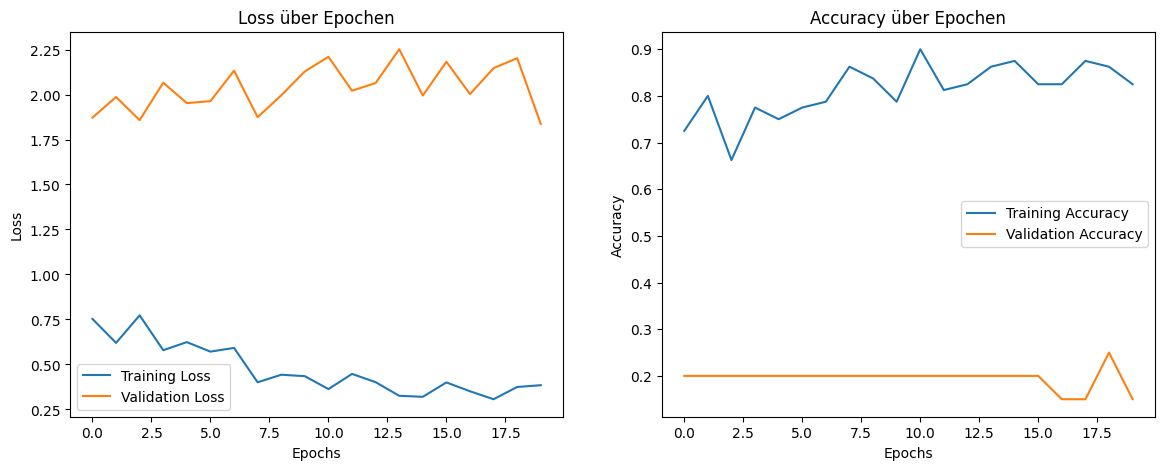

In [37]:
# Plot Loss (Verlust plotten)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss über Epochen')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy (Genauigkeit plotten)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy über Epochen')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [38]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 30752)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │       3,936,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,813,777 (45.07 MB)

 Trainable params: 3,937,925 (15.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,875,852 (30.04 MB)

The results of the deep learning model show a high accuracy of 0.9451% after 10 epochs (and 1.00% after 20 ep.), with a loss of 0.3621. The validation accuracy is 0.8406%, indicating good generalizability of the model. These results suggest that the model is able to effectively differentiate between with to distinguish between the two pistachio varieties 'kirmizi' and 'siirt'.

**Modell save**

In [48]:
model.save('pistachio_model.h5')

In [49]:
model.save('pistachio_model.keras')

**Modell load**

To reload the model later, you can use the following:

In [50]:
loaded_model = tf.keras.models.load_model('pistachio_model.keras')